# **05. House Price Segmentation Analysis**


## **Introduction**

I’ll use the **CRISP-DM process** to explore the Kaggle Ames Housing dataset and answer three key housing-market questions using its 79 features.


### **Objectives**

I'll use the **CRISP-DM process** to explore three key questions using the Ames Housing dataset:

1. **What are the typical house price ranges?** — Identify major price brackets and market segments.
2. **Which neighborhoods\location correspond to these price ranges?** — Explore how prices vary across locations.
3. **Which features determine a property's price bracket?** — Identify the key factors influencing house prices.

The analysis will cover data preparation, feature engineering, modeling, and interpretation to uncover meaningful housing-market insights.



## **1. Dataset Info**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
import kaggle
import os
import zipfile
from pathlib import Path
import pickle
import joblib
from math import expm1
from IPython.display import display
from IPython.display import Markdown
%matplotlib inline
sns.set_style('darkgrid')


In [2]:
# dispaly setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))



In [3]:
# Define path to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_data_file = parent_path.joinpath("data", "processed")

# will read original dataset
files = []
for file in data_path.rglob("*.csv"):
    files.append(file)
    print(files.index(file), " ", file.name)

print("\n") 

# Will read the processed data which stores in notebook "01-Data-Cleaning"
clean_files = []
for file in processed_data_file.glob("*"):
    clean_files.append(file)
    print(clean_files.index(file), " ", file.name)


0   sample_submission.csv
1   test.csv
2   train.csv


0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [4]:
display_md("**Loading Cleaned & Original Dataset....**")
# Load necessary data and model
try:
    # Load cleaned data from notebook "01-Data-Cleaning"
    train_cleaned = pd.read_csv(clean_files[2])
    test_cleaned = pd.read_csv(clean_files[1])
    
    # Load original data for reference and insights
    train_org = pd.read_csv(files[2])
    test_org = pd.read_csv(files[1])    

    # standardize the column names
    train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    test_org.columns = test_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # Drop rows where YrSold < YearRemodAdd
    train_original = train_org[train_org['YrSold'] >= train_org['YearRemodAdd']]

    display_md("**Data load successfully....**")
    display_md("**Cleaned Training and Testing data Shape**")
    print("Cleaned Training data shape: ", train_cleaned.shape)
    print("Cleaned Testing data shape: ", test_cleaned.shape)

    display_md("**Original Training and Testing data Shape**")
    print("Original Training data shape: ", train_org.shape)
    print("Original Testing data shape: ", test_org.shape)
    display_md("**Duplicate Rows in Cleaned Data**")
    print("Number of duplicate rows in cleaned training data: ", train_cleaned.duplicated().sum())
    print("Number of duplicate rows in cleaned testing data ", test_cleaned.duplicated().sum())
except Exception as e:
    print(f"ErrorRaised  {e}")

**Loading Cleaned & Original Dataset....**

**Data load successfully....**

**Cleaned Training and Testing data Shape**

Cleaned Training data shape:  (1460, 81)
Cleaned Testing data shape:  (1459, 80)


**Original Training and Testing data Shape**

Original Training data shape:  (1460, 81)
Original Testing data shape:  (1459, 80)


**Duplicate Rows in Cleaned Data**

Number of duplicate rows in cleaned training data:  0
Number of duplicate rows in cleaned testing data  0


In [5]:
# Data type in train and test datasets should be same for all columns. Let's check that.
print(train_cleaned.dtypes.value_counts())
print(test_cleaned.dtypes.value_counts())


object     43
int64      35
float64     3
Name: count, dtype: int64
object     43
int64      26
float64    11
Name: count, dtype: int64


In [6]:
train_cleaned['GarageYrBlt'] = train_cleaned['GarageYrBlt'].astype('int64')
test_cleaned[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea']] = test_cleaned[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea']].astype('int64')


In [7]:
# check data types of train and test datasets after conversion
print(train_cleaned.dtypes.value_counts())
print(test_cleaned.dtypes.value_counts())

object     43
int64      36
float64     2
Name: count, dtype: int64
object     43
int64      35
float64     2
Name: count, dtype: int64


In [8]:
display_md("**Training data columns:**")
display(train_org.columns)

**Training data columns:**

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [9]:
# Definition of Features Types
display_md("**Segregrate Columns by Data Types**")
year_features = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold']
ordinal_features = ["OverallQual", "OverallCond", "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "LotShape", "Fence", "Functional", "LandSlope", "PavedDrive"]
numerical_features = [col for col in train_cleaned.select_dtypes(include=np.number).columns if col not in ordinal_features + year_features and col not in ['SalePrice', 'Id', 'MSSubClass']]
categorical_features = [col for col in train_cleaned.select_dtypes(include='object').columns if col not in ordinal_features + year_features] + ['MSSubClass']



**Segregrate Columns by Data Types**

## **2. Exploratory Data Analysis**

**2.1. Sale Price**

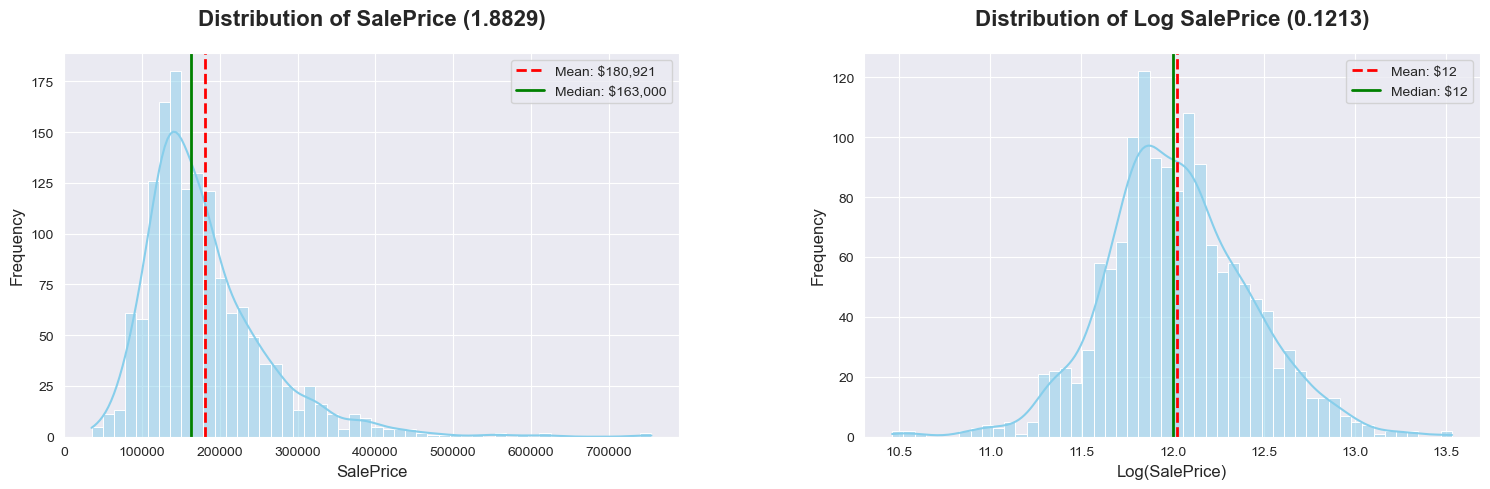

In [12]:
# Calculate statistics
y = train_org['SalePrice']
mean_price = y.mean()
median_price = y.median()

log_y = np.log1p(y)

(f"""Skewness : {y.skew():.4f}
Kurtosis : {y.kurtosis():.4f}""") # kurtosis > 3 means heavy tails, more outliers than normal.

# Plot histogram with KDE
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(y, kde=True, bins=50, color='skyblue', ax=ax[0])

# Add mean and median lines
ax[0].axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: ${mean_price:,.0f}")
ax[0].axvline(median_price, color="green", linestyle="-", linewidth=2, label=f"Median: ${median_price:,.0f}")

# Labels and legend
fig.subplots_adjust(bottom=0.2)
ax[0].set_title(f"Distribution of SalePrice ({y.skew():.4f})", fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel("SalePrice", fontsize=12)
ax[0].set_ylabel("Frequency", fontsize=12)
ax[0].legend()


# boxplot of SalePrice for outliers
sns.histplot(log_y, kde=True, bins=50, color='skyblue', ax=ax[1])

# Add mean and median lines
ax[1].axvline(log_y.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: ${log_y.mean():,.0f}")
ax[1].axvline(log_y.median(), color="green", linestyle="-", linewidth=2, label=f"Median: ${log_y.median():,.0f}")

# Labels and legend
ax[1].set_title(f"Distribution of Log SalePrice ({log_y.skew():.4f})", fontsize='16', fontweight='bold', pad=20)
ax[1].set_xlabel("Log(SalePrice)", fontsize=12)
ax[1].set_ylabel("Frequency", fontsize=12)
ax[1].legend()

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

- The distribution of `SalePrice` is right-skewed. So, we can consider transformation to reduce skewness before modeling.
- Sale prices range form USD 34,900 to USD 755,000.
- And this is `SalePrice` after log transformation. The sknewness has been fixed.


##### **2.2. Missing Values**

Most ML algorithms cannot handle missing values directly, so they must be identified and either removed or imputed before modeling.


In [13]:
miss_df = train_org.stb.missing().query("percent > 6")
miss_df = miss_df.assign(dtype = [train_org[col].dtype for col in miss_df.index])
display(miss_df)
# criteria remove columns with more than 6% missing values


,missing,total,percent,dtype
PoolQC,1453,1460,99.520548,object
MiscFeature,1406,1460,96.301370,object
Alley,1369,1460,93.767123,object
Fence,1179,1460,80.753425,object
MasVnrType,872,1460,59.726027,object
FireplaceQu,690,1460,47.260274,object
LotFrontage,259,1460,17.739726,float64


In [14]:
# remove 'LotFrontage' from numeric_features
num_col = [col for col in numerical_features if col != 'LotFrontage']

# remove 'PoolQC', 'FireplaceQu', 'Fence' from ordinal_features
ord_col = [col for col in ordinal_features if col not in ['PoolQC', 'FireplaceQu', 'Fence']]

# remove 'MiscFeature', 'Alley', 'MasVnrType' from categorical_features
cat_col = [col for col in categorical_features if col not in ['MiscFeature', 'Alley', 'MasVnrType']]

# keep year features as they are
year_col = year_features


##### **2.3. Outliers Treatment**

Because regression models are very sensitive to outlier, we need to be aware of them. Let's examine outliers with a scatter plot.



In [15]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame)The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""

numeric_df = train_cleaned[num_col]
outliers_percentages = {}
for col in numeric_df.columns:
    x_low, x_high = np.percentile(numeric_df[col].dropna(),[1,99])
    total_values = len(numeric_df[col])
    outliers = len(numeric_df[~numeric_df[col].between(x_low,x_high)])
    outliers_percentage = round((outliers / total_values)*100 , 2)
    outliers_percentages[col] = outliers_percentage
    
outliers_df = pd.DataFrame(list(outliers_percentages.items()), columns=['Features','Outliers Percentage'])
outliers_data = outliers_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True)
outliers_data.head()


,Features,Outliers Percentage
0,GrLivArea,2.05
1,1stFlrSF,1.85
2,LotArea,1.51
3,GarageArea,1.03
4,BsmtFinSF1,1.03


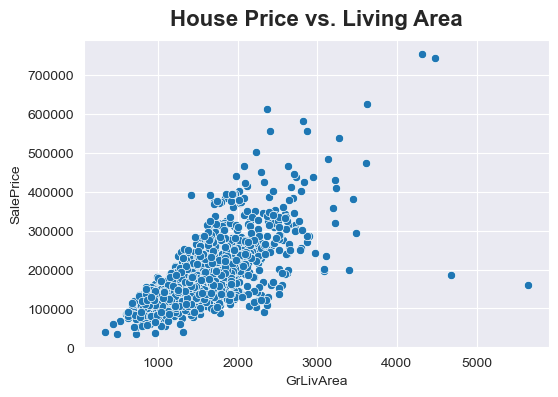

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_cleaned[num_col + ['SalePrice']], ax=ax)
ax.set_title('House Price vs. Living Area', fontsize=16, fontweight='bold', y=1.02)
plt.show()


Two observations stand out as outliers, with unusually large living areas but relatively low prices. These outliers will be removed from the training set.


In [17]:
display_md("**Outliers Treatment**")
outlier_index = train_cleaned[(train_cleaned.GrLivArea > 4000)
                           & (train_cleaned.SalePrice < 200000)].index
train_cleaned.drop(outlier_index, axis="index", inplace=True)
y.drop(outlier_index, axis="index", inplace=True)


**Outliers Treatment**

##### **2.4. Skewness of Explanatory Features**

Next, I analyze the skewness of the explanatory variables using a bar plot. Since linear regression can be sensitive to highly skewed predictors, transforming skewed features can help improve model fit and performance.


**Skewness in Explanatory Variables**

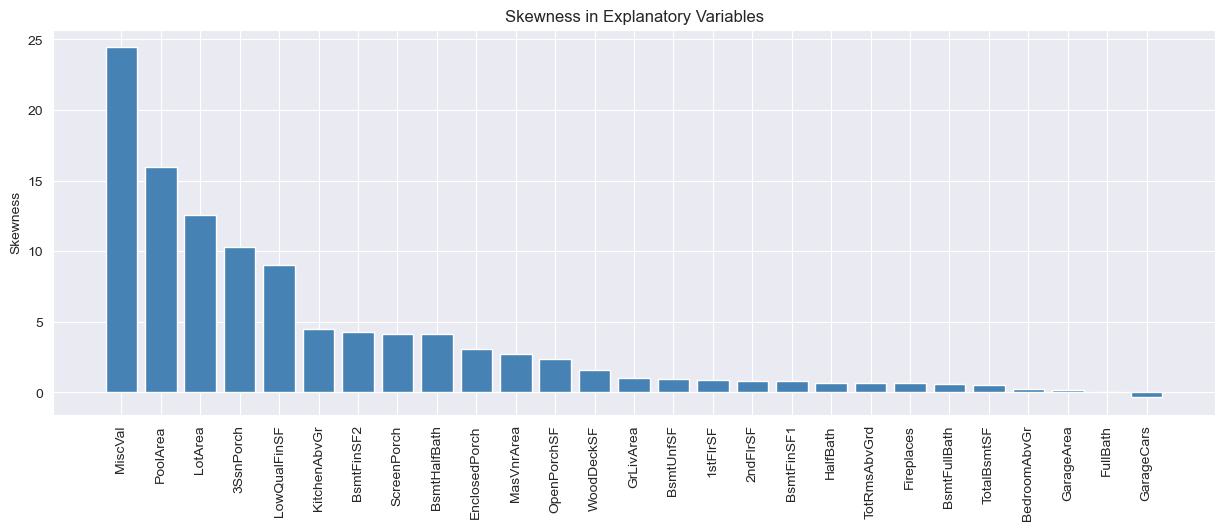

In [18]:
import matplotlib.pyplot as plt

def show_explanatory_variables_skewness(process_data, numerical_features):
    # Calculate skewness
    skew_study_data = process_data[numerical_features].skew()
    skew_merged = pd.DataFrame(data=skew_study_data, columns=['Skewness'])
    skew_merged_sorted = skew_merged.sort_values(by='Skewness', ascending=False)

    # Plot with Matplotlib
    plt.figure(figsize=(15,5))
    plt.bar(skew_merged_sorted.index, skew_merged_sorted['Skewness'], color='steelblue')
    plt.xticks(rotation=90)
    plt.title('Skewness in Explanatory Variables')
    plt.ylabel('Skewness')
    plt.show()


# Apply the function 
display_md("**Skewness in Explanatory Variables**")
show_explanatory_variables_skewness(train_cleaned, num_col)


The bar plot shows several right-skewed variables. I apply a natural log transformation to features with skewness above 0.75 to reduce skewness and improve their distributions.


In [19]:
display_md('**Features to be transformed (skewness>0.75):**')

skew_study_data = train_cleaned[num_col].skew()
filtered_skew_study_data = skew_study_data[skew_study_data>0.75]
skewed_columns = filtered_skew_study_data.index.values

display(skewed_columns)

for col in skewed_columns:
    train_cleaned[col] = np.log1p(train_cleaned[col])
    test_cleaned[col] = np.log1p(test_cleaned[col])
    

**Features to be transformed (skewness>0.75):**

array(['LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtHalfBath', 'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'],
      dtype=object)

##### **2.5. Bivariate Analysis with SalePrice**

I performed bivariate analysis to identify the 10 variables most strongly correlated with `SalePrice`, encoding categorical and ordinal features on a 0–1 scale for consistency.


In [20]:
from sklearn.preprocessing import LabelEncoder
train_df = train_cleaned.copy()

for col in cat_col:
    label_encoder = LabelEncoder()
    train_df[col] = label_encoder.fit_transform(train_df[col])

for col in ord_col:
    label_encoder = LabelEncoder()
    train_df[col] = label_encoder.fit_transform(train_df[col])


display(train_df[num_col + ord_col + cat_col + year_col].head())

df_corr = np.round(train_df[num_col + ord_col + cat_col + year_col + ['SalePrice']].corr(), 2)

display_md('**Best 10 Positively Correlated Variables:**')
display(df_corr['SalePrice'].sort_values(ascending = False)[:11])

display_md('**Best 10 Negatively Correlated Variables:**')
display(df_corr['SalePrice'].sort_values(ascending = False)[-10:])


,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,OverallQual,OverallCond,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,GarageFinish,GarageQual,GarageCond,LotShape,Functional,LandSlope,PavedDrive,MSZoning,Street,LandContour,Utilities,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,Foundation,Heating,CentralAir,Electrical,GarageType,SaleType,SaleCondition,MSSubClass,YearBuilt,YearRemodAdd,GarageYrBlt,MoSold,YrSold
0,9.042040,5.283204,6.561031,0.0,5.017280,856,6.753438,6.751101,0.0,7.444833,1,0.000000,2,1,3,0.693147,8,0,2,548,0.000000,4.127134,0.000000,0.0,0.0,0.0,0.0,6,4,2,4,2,4,3,2,6,0,2,2,5,5,3,6,0,2,3,1,3,0,4,5,2,2,0,5,1,0,12,13,2,1,1,4,1,8,4,5,2003,2003,2003,2,2008
1,9.169623,0.000000,6.886532,0.0,5.652489,1262,7.141245,0.000000,0.0,7.141245,0,0.693147,2,0,3,0.693147,6,1,2,460,5.700444,0.000000,0.000000,0.0,0.0,0.0,0.0,5,7,3,4,2,4,1,0,6,0,3,2,5,5,3,6,0,2,3,1,3,0,2,24,1,2,0,2,1,0,8,8,1,1,1,4,1,8,4,0,1976,1976,1976,5,2007
2,9.328212,5.093750,6.188264,0.0,6.075346,920,6.825460,6.765039,0.0,7.488294,1,0.000000,2,1,3,0.693147,6,1,2,608,0.000000,3.761200,0.000000,0.0,0.0,0.0,0.0,6,4,2,4,2,4,2,2,6,0,2,2,5,5,0,6,0,2,3,1,3,0,4,5,2,2,0,5,1,0,12,13,2,1,1,4,1,8,4,5,2001,2002,2001,9,2008
3,9.164401,0.000000,5.379897,0.0,6.293419,756,6.869014,6.629363,0.0,7.448916,1,0.000000,1,0,3,0.693147,7,1,3,642,0.000000,3.583519,5.609472,0.0,0.0,0.0,0.0,6,4,3,4,4,1,3,0,6,2,2,3,5,5,0,6,0,2,3,1,3,0,0,6,2,2,0,5,1,0,13,15,0,1,1,4,5,8,0,6,1915,1970,1998,2,2006
4,9.565284,5.860786,6.486161,0.0,6.196444,1145,7.044033,6.960348,0.0,7.695758,1,0.000000,2,1,4,0.693147,9,1,3,836,5.262690,4.442651,0.000000,0.0,0.0,0.0,0.0,7,4,2,4,2,4,0,2,6,0,2,2,5,5,0,6,0,2,3,1,3,0,2,15,2,2,0,5,1,0,12,13,2,1,1,4,1,8,4,5,2000,2000,2000,12,2008


**Best 10 Positively Correlated Variables:**

SalePrice       1.00
OverallQual     0.80
GrLivArea       0.70
TotalBsmtSF     0.65
GarageCars      0.64
GarageArea      0.63
1stFlrSF        0.60
FullBath        0.56
TotRmsAbvGrd    0.54
YearBuilt       0.52
GarageYrBlt     0.51
Name: SalePrice, dtype: float64

**Best 10 Negatively Correlated Variables:**

MSZoning        -0.17
EnclosedPorch   -0.18
LotShape        -0.26
BsmtExposure    -0.30
HeatingQC       -0.40
GarageType      -0.42
GarageFinish    -0.43
KitchenQual     -0.59
BsmtQual        -0.60
ExterQual       -0.64
Name: SalePrice, dtype: float64

## **3. Feature Engineering**

| Feature | Description |
|---|---|
| `TotalSF` | Total living area calculated from basement, first-floor, and second-floor square footage. |
| `YrBltAndRemod` | Combines the year built and year remodeled to represent the property's age and updates. |
| `TotalBathrooms` | Total bathrooms, including full and half bathrooms in the main living area and basement. |
| `QualCond`, `ExterQualCond`, `GarageQualCond`, `BsmtQualCond` | Combined quality and condition features for the overall house, exterior, garage, and basement. |
| `hasPool`, `hasGarage`, `hasBsmt`, `hasFireplace`, `hasporch` | Binary features indicating whether the property has a pool, garage, basement, fireplace, or porch. |
| `house_age` | House age calculated as `YrSold - YearBuilt`. |
| `garage_age` | Garage age calculated as `YrSold - GarageYrBlt`. |
| `old_house` | Binary feature indicating whether the house was built before 1900. |


In [21]:
def feature_engineering(df):
    result = df.copy()
    
    result['TotalSF'] = result['TotalBsmtSF'] + result['1stFlrSF'] + result['2ndFlrSF']
    
    result['YrBltAndRemod'] = result['YearBuilt'] + result['YearRemodAdd']
    
    result['Total_Bathrooms'] = (result['FullBath']
                                + (0.5 * result['HalfBath'])
                                + result['BsmtFullBath']
                                + (0.5 * result['BsmtHalfBath'])
                                )

    result['OverallQualCond'] = result['OverallQual'] * 100 + result['OverallCond']
    result['ExterQualCond'] = result['ExterQual'] + result['ExterCond']
    result['BsmtQualCond'] = result['BsmtQual'] + result['BsmtCond']
    result['GarageQualCond'] = result['GarageQual'] + result['GarageCond']
    
    result['HasPool'] = result['PoolArea'].apply(lambda x: 1 if x > 0 else 0).astype('bool')
    result['HasGarage'] = result['GarageArea'].apply(lambda x: 1 if x > 0 else 0).astype('bool')
    result['HasBsmt'] = result['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0).astype('bool')
    result['HasFireplace'] = result['Fireplaces'].apply(lambda x: 1 if x > 0 else 0).astype('bool')
    result['HasPorch'] = (result['OpenPorchSF'] > 0).astype('bool')


    result['HouseAge'] = result['YrSold'] - result['YearBuilt']
    result['GarageAge'] = result['YrSold'] - result['GarageYrBlt']
    result['OldHouse'] = np.where(result['YearBuilt'] < 1900, 1, 0).astype('bool')

    return result


# Applying feature engineering to both train and test datasets
print("="*20, "Applying feature engineering to datasets...", "="*20)
train_df = train_cleaned[num_col + ord_col + cat_col + year_col + ['SalePrice']].copy()
test_df = test_cleaned[num_col + ord_col + cat_col + year_col].copy()
train_processed = feature_engineering(train_df)
test_processed = feature_engineering(test_df)


==================== Applying feature engineering to datasets... ====================


In [22]:
display(train_processed.dtypes.value_counts())
display(test_processed.dtypes.value_counts())


object     40
int64      22
float64    20
bool        6
Name: count, dtype: int64

object     40
int64      21
float64    20
bool        6
Name: count, dtype: int64

In [23]:
# Defining features according to their types for further processing and modeling
year_columns = year_col
ordinal_columns = ord_col + ['OverallQualCond', 'ExterQualCond', 'BsmtQualCond', 'GarageQualCond']
boolean_columns = [col for col in train_processed.select_dtypes(include='bool').columns]
num_columns = [col for col in train_processed.select_dtypes(include=np.number).columns if col not in ordinal_columns + year_columns + boolean_columns + ['SalePrice', 'Id', 'MSSubClass']]
cat_columns = [col for col in train_processed.select_dtypes(include='object').columns if col not in ordinal_columns + year_columns + boolean_columns] + ['MSSubClass']



## **4. Modelling**

#### **4.1. Train Test Dataset**

In [24]:
total_features = num_columns + ordinal_columns + cat_columns + year_columns + boolean_columns
X_train = train_processed[total_features]
X_test = test_processed[total_features]
y_train = np.log1p(train_processed['SalePrice'])


#### **4.2. Preprocessing Pipeline**

### **Feature Scaling**

Most ML models benefit from standardized features, while tree-based models such as Decision Trees and Random Forests generally do not require scaling. I use `StandardScaler` to standardize the training data.

### **One-Hot Encoding**

Categorical and ordinal features are one-hot encoded to avoid imposing artificial numerical relationships between categories.


In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), num_columns),
    ('ordinal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ordinal_columns),
    ('boolean', 'passthrough', boolean_columns),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_columns),
    ('year', 'passthrough', year_columns)
])


**I will apply these transformations during model training while focusing on the objectives defined earlier.**


## **5. Insights into the Ames, Iowa Housing Market**

The following analysis addresses the research questions defined in the Objectives section.


### **1. What are the typical house price ranges in the Ames dataset?**

To identify the primary house price ranges in the Ames, Iowa dataset, I applied three clustering techniques to the SalePrice variable. Clustering groups similar price values together, and each method offers different insights on the housing market.

| Method | Description |
|---|---|
| **K-means Clustering with Elbow Method** | Applies K-means clustering to segment houses by price. The Elbow Method determines the optimal number of clusters by identifying the point where adding more clusters produces diminishing improvements in model fit. |
| **K-means Clustering with Silhouette Analysis** | Applies K-means clustering and uses the Silhouette Score to evaluate how well each house fits within its assigned cluster compared with other clusters. This helps determine an effective number of clusters for meaningful grouping. |
| **Gaussian Mixture Model with BIC** | Uses Gaussian Mixture Models (GMM), which allow clusters to have more flexible shapes than K-means. The Bayesian Information Criterion (BIC) balances model fit and complexity to guide the selection of the appropriate number of clusters. |


#### **5.1. K-means Clustering with Elbow Method**

In [26]:
# I will use the log-transformed SalePrice values during training, since leaving them untransformed can negatively impact distance-based algorithms.
clustering_df = train_processed[total_features + ['SalePrice']].copy()
clustering_df['LogSalePrice'] = np.log1p(clustering_df['SalePrice'])

# NOTE: df[[col]].values → returns a 2D array with shape (n, 1).
# Exactly — StandardScaler.fit() requires a 2D array as input
sale_price = clustering_df[['LogSalePrice']].values

# before clustering, we need to scale the saleprice
scale = StandardScaler()
scaled_sale_price = scale.fit_transform(sale_price)


no_cluster,wcss,explained_variance(%),pct_explained_variance
1,1458.000000,-0.000000,nan
2,576.305830,0.604700,0.604700
3,324.571253,0.777400,0.172700
4,198.677097,0.863700,0.086300
5,134.667337,0.907600,0.043900
6,109.611810,0.924800,0.017200
7,78.266816,0.946300,0.021500
8,64.801776,0.955600,0.009300
9,47.935756,0.967100,0.011500
10,39.339666,0.973000,0.005900


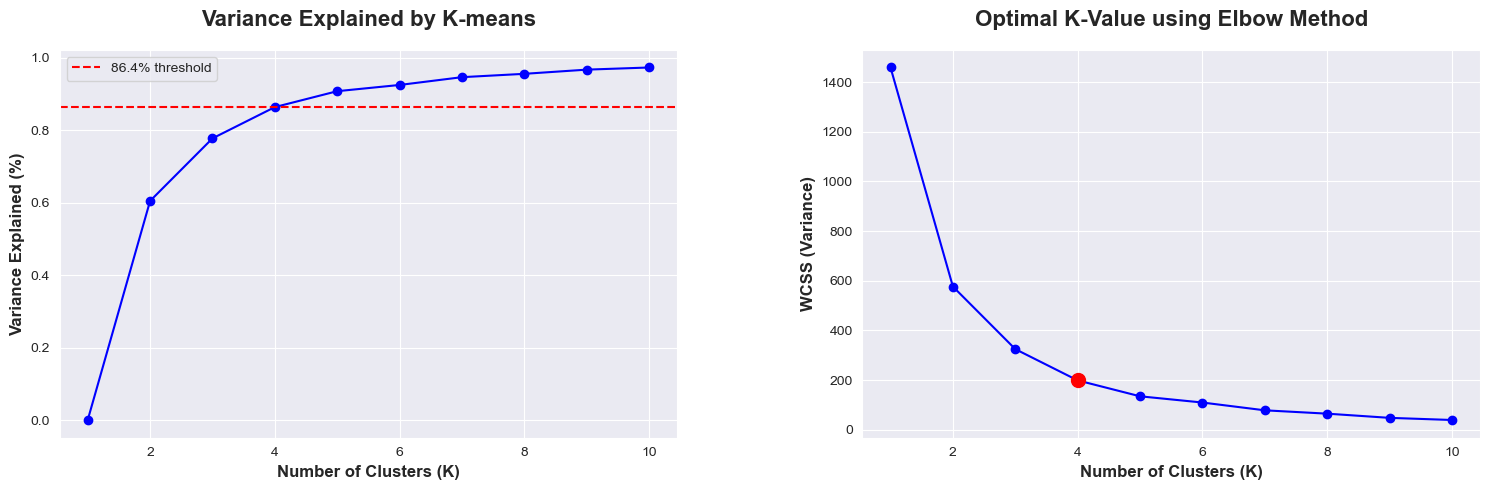

In [27]:
X = scaled_sale_price
# Total variance = sum of squared distances from mean
total_variance = np.sum((X - np.mean(X))**2)

# KMeans Clustering and variance explained calculation
explained_variance = []
wcss = []
n_cluster = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    inertias = kmeans.inertia_  # within-cluster sum of squares
    wcss.append(inertias)
    bcss = total_variance - inertias  # between-cluster sum of squares
    explained_variance.append(bcss / total_variance)
    n_cluster.append(k)

# create dataframe
cluster_dfs = pd.DataFrame([], columns=['no_cluster', 'wcss', 'explained_variance(%)'])
cluster_dfs['no_cluster'] = n_cluster
cluster_dfs['wcss'] = wcss
cluster_dfs['explained_variance(%)'] = explained_variance
cluster_dfs['explained_variance(%)'] = cluster_dfs['explained_variance(%)'].map(lambda x: f'{x:.4f}').astype('float')
cluster_dfs = cluster_dfs.assign(pct_explained_variance=cluster_dfs['explained_variance(%)'].diff())
display(cluster_dfs.style.hide(axis='index'))

# plot 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot no. of clusters with variance explained
value = cluster_dfs.loc[cluster_dfs['no_cluster']==4, 'explained_variance(%)'].iloc[0]
ax[0].plot(K, explained_variance, 'bo-')
ax[0].axhline(y=value, color='r', ls='--', label=f'{value:.1%} threshold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax[0].set_title('Variance Explained by K-means', fontsize=16, fontweight='bold', y=1.04)
ax[0].legend()

# plot no. of clusters with elbow method
wcss_value = cluster_dfs.loc[cluster_dfs['no_cluster']==4, 'wcss'].iloc[0]
ax[1].plot(K, wcss, 'bo-')
ax[1].scatter(4, wcss_value, color='r', s=100, zorder=5)
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('WCSS (Variance)', fontsize=12, fontweight='bold')
ax[1].set_title('Optimal K-Value using Elbow Method', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()



Cluster 3: Mean SalePrice = $82.26K
Cluster 0: Mean SalePrice = $133.02K
Cluster 2: Mean SalePrice = $194.55K
Cluster 1: Mean SalePrice = $314.65K



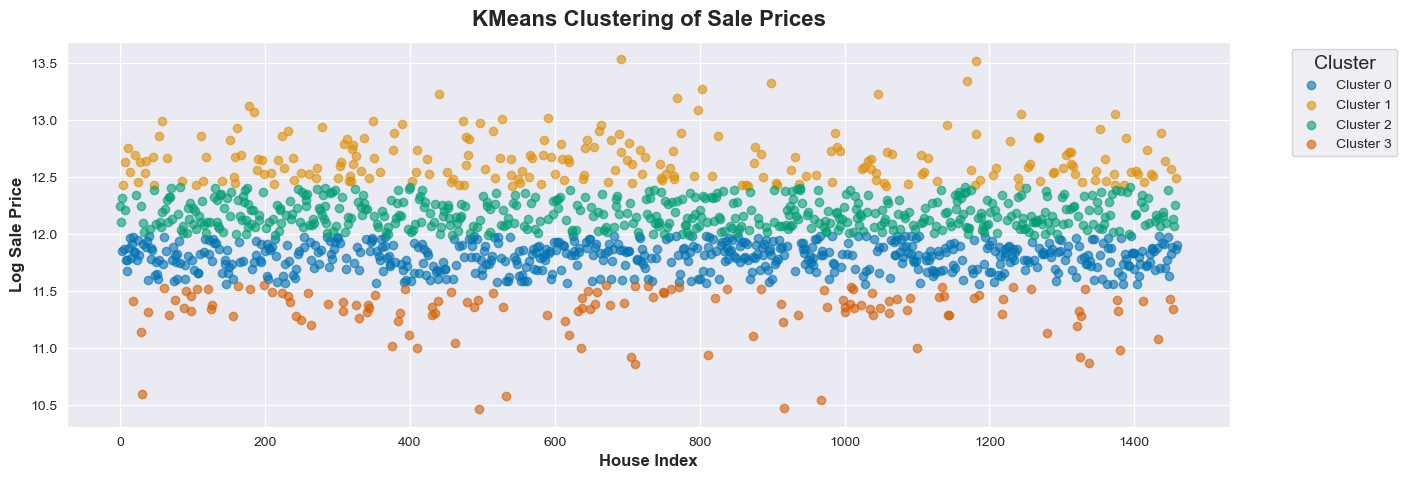

In [28]:
# Define a color-blind friendly palette
# Using a palette from ColorBrewer which is designed to be color-blind friendly
colorblind_palette = sns.color_palette("colorblind", n_colors=8)

# I'll choose the smallest k that explains at least 85% + of the variance, which is k=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
kmeans.fit(scaled_sale_price)

# Add cluster labels to the original DataFrame
clustering_df['Cluster'] = kmeans.labels_

# Compute mean SalePrice for each cluster
cluster_means = clustering_df.groupby('Cluster')['LogSalePrice'].mean().sort_values()

for cluster, mean_price in cluster_means.items():
    print(f"Cluster {cluster}: Mean SalePrice = ${expm1(mean_price)/1000:.2f}K")

# Visualize the clusters
print()
plt.figure(figsize=(15, 5))
for i in range(n_clusters):
    cluster_data = clustering_df[clustering_df['Cluster'] == i]
    plt.scatter(cluster_data.index, cluster_data['LogSalePrice'], label=f'Cluster {i}', alpha=0.6, color=colorblind_palette[i])

plt.xlabel('House Index', fontsize=12, fontweight='bold')
plt.ylabel('Log Sale Price', fontsize=12, fontweight='bold')
plt.title('KMeans Clustering of Sale Prices', fontsize=16, fontweight='bold', y=1.02)
plt.legend(title='Cluster', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1), fancybox=True)
plt.show()


#### **5.2. K-means Clustering with Silhouette Analysis:**


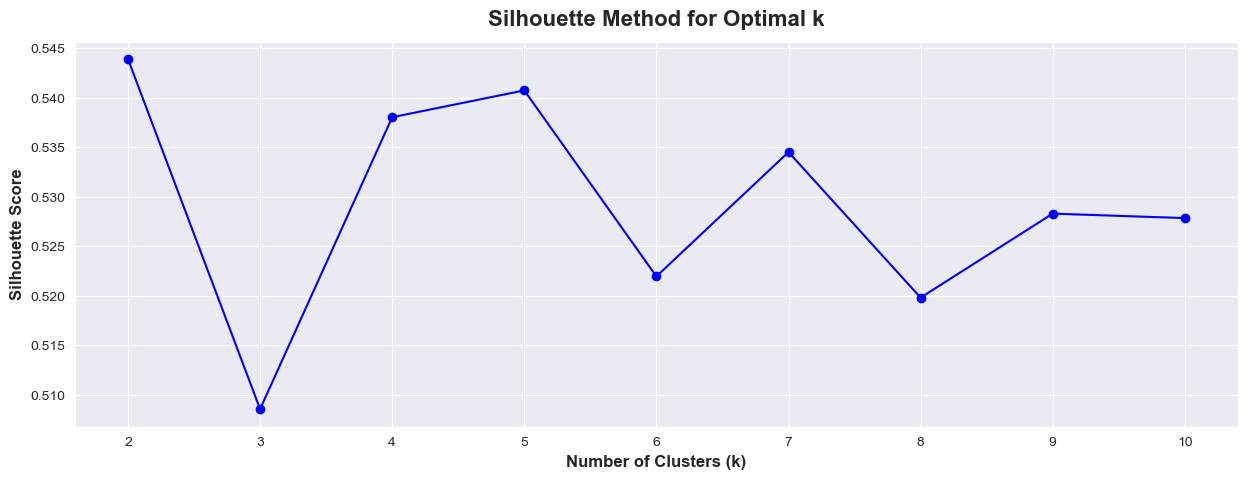

Optimal number of clusters: 2
Cluster 0: Mean Price = $126.11K
Cluster 1: Mean Price = $235.62K



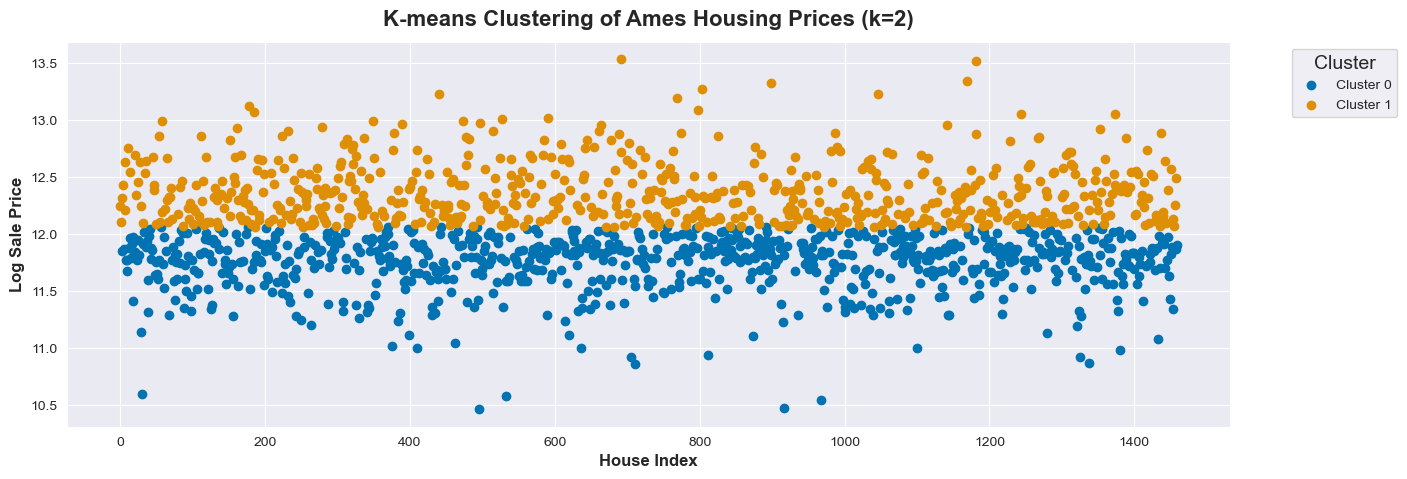

In [29]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters as silhouette score is not defined for 1 cluster

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_sale_price)
    score = silhouette_score(scaled_sale_price, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(15, 5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Method for Optimal k', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Find the optimal number of clusters (highest silhouette score)
optimal_k = K[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

# Perform K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(scaled_sale_price)

# Add cluster labels to the original dataframe
# Add cluster labels to the original dataframe
clustering_data = pd.DataFrame(train_processed[total_features + ['SalePrice']])
clustering_data['LogSalePrice'] = np.log1p(clustering_data['SalePrice'])    
clustering_data['Cluster'] = kmeans.labels_

# Calculate the mean price for each cluster
cluster_means = clustering_data.groupby('Cluster')['LogSalePrice'].mean().sort_values()

# Print the mean prices for each cluster
for cluster, mean_price in cluster_means.items():
    print(f"Cluster {cluster}: Mean Price = ${expm1(mean_price)/1000:.2f}K")

# Visualize the clusters
print()
plt.figure(figsize=(15, 5))
for i in range(optimal_k):
    cluster_data = clustering_data[clustering_data['Cluster'] == i]
    plt.scatter(cluster_data.index, cluster_data['LogSalePrice'], label=f'Cluster {i}', color=colorblind_palette[i])

plt.xlabel('House Index',fontsize=12, fontweight='bold')
plt.ylabel('Log Sale Price', fontsize=12, fontweight='bold')
plt.title(f'K-means Clustering of Ames Housing Prices (k={optimal_k})', fontsize=16, fontweight='bold', y=1.02)
plt.legend(title='Cluster', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1), fancybox=True)
plt.show()

#### **5.3. Gaussian Mixture Model with BIC:**


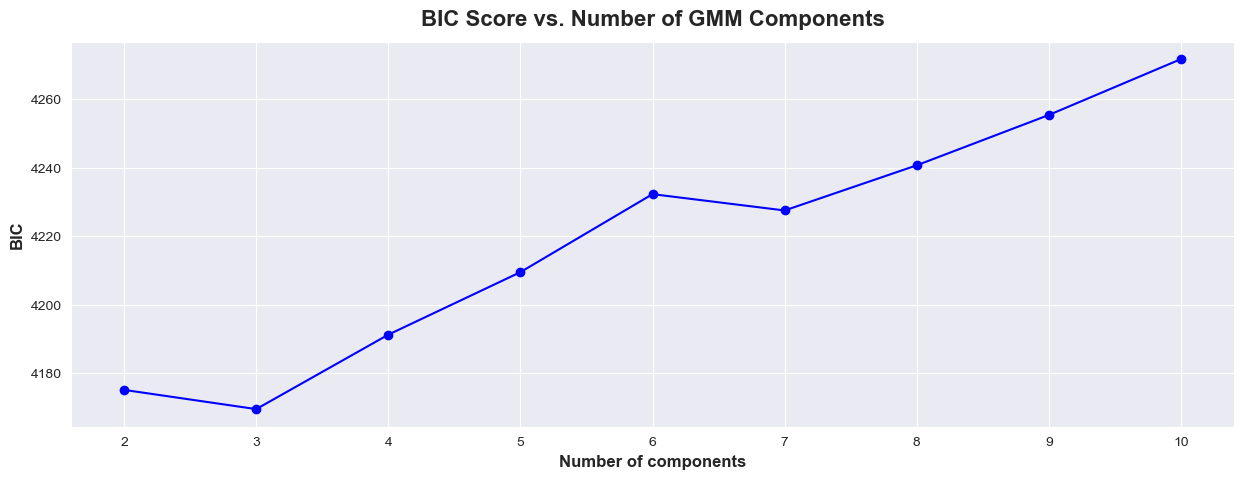

The optimal number of components based on BIC: 3

Cluster 0: Mean Price = $92.98K
Cluster 2: Mean Price = $159.32K
Cluster 1: Mean Price = $294.39K



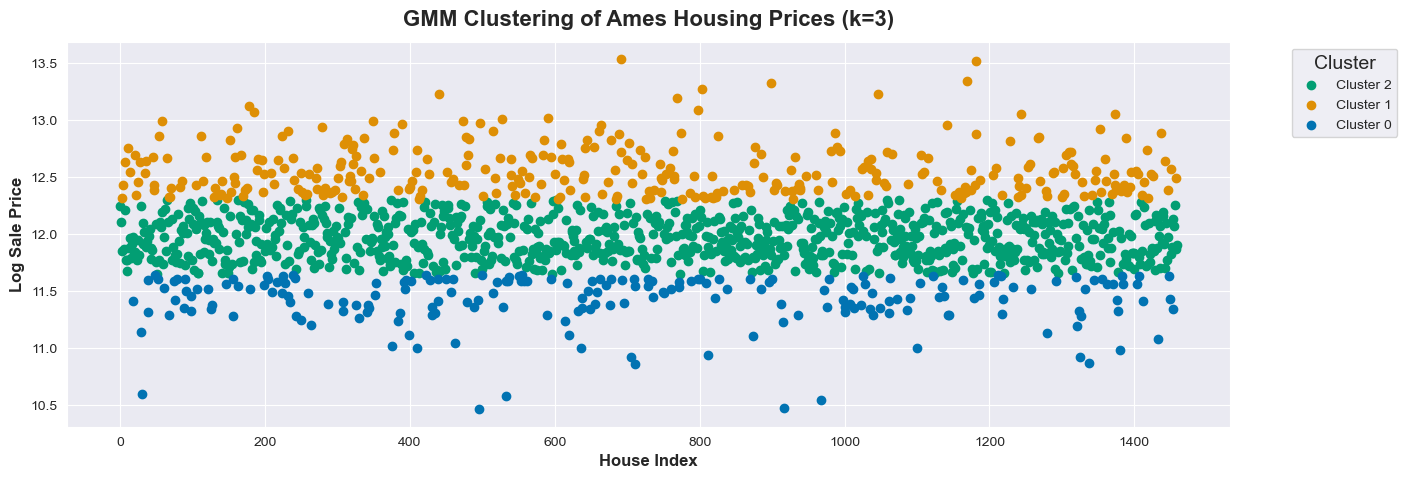

In [30]:
from sklearn.mixture import GaussianMixture

# compute BIC and silhouette scores for different numbers of components
n_components_range = range(2, 11)
bic = []
silhouette_scores = []

for n_components in n_components_range:
    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(scaled_sale_price)

    # Calculate BIC score
    bic.append(gmm.bic(scaled_sale_price))

# Plot the BIC scores
print()
plt.figure(figsize=(15, 5))
plt.plot(n_components_range, bic, 'bo-')
plt.xlabel('Number of components', fontsize=12, fontweight='bold')
plt.ylabel('BIC', fontsize=12, fontweight='bold')
plt.title('BIC Score vs. Number of GMM Components', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Find the optimal number of components (lowest BIC)
optimal_components = n_components_range[np.argmin(bic)]
print(f"The optimal number of components based on BIC: {optimal_components}\n")

# Fit GMM with the optimal number of components
gmm = GaussianMixture(n_components=optimal_components, random_state=42)
gmm.fit(scaled_sale_price)

# Add cluster labels to the original dataframe
gmm_clustering_df = pd.DataFrame(train_processed[total_features + ['SalePrice']])
gmm_clustering_df['LogSalePrice'] = np.log1p(gmm_clustering_df['SalePrice'])
gmm_clustering_df['Cluster'] = gmm.predict(scaled_sale_price)

# Calculate the mean price for each cluster
gmm_cluster_saleprice = gmm_clustering_df.groupby('Cluster')['SalePrice']
gmm_cluster_means = gmm_cluster_saleprice.mean().sort_values()
gmm_cluster_min = gmm_cluster_saleprice.min().sort_values()
gmm_cluster_max = gmm_cluster_saleprice.max().sort_values()

# Print the mean prices for each cluster
for cluster, mean_price in gmm_cluster_means.items():
    print(f"Cluster {cluster}: Mean Price = ${(mean_price)/1000:.2f}K")

# Visualize the clusters
print()
plt.figure(figsize=(15, 5))
for i in gmm_clustering_df['Cluster'].unique():
    cluster_data = gmm_clustering_df[gmm_clustering_df['Cluster'] == i]
    plt.scatter(cluster_data.index, cluster_data['LogSalePrice'], label=f'Cluster {i}', color=colorblind_palette[i])

plt.xlabel('House Index', fontsize=12, fontweight='bold')
plt.ylabel('Log Sale Price', fontsize=12, fontweight='bold')
plt.title(f'GMM Clustering of Ames Housing Prices (k={optimal_components})', fontsize=16, fontweight='bold', y=1.02)
plt.legend(title='Cluster', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1), fancybox=True)
plt.show()


#### **Clustering Analysis of SalePrice in the Ames Housing Dataset**

| **Clustering Method** | **Optimal Number of Clusters** |
|---|---:|
| **K-means Clustering + Elbow Method Optimization** | 4 |
| **K-means Clustering + Silhouette Score Optimization** | 2 |
| **Gaussian Mixture Model + Bayesian Information Criterion (BIC)** | 3 |

To maintain interpretability and present a clearer picture of the Ames housing market, the **Gaussian Mixture Model with Bayesian Information Criterion (BIC)** selected, which defines three distinct segments according to sale price ranges:



#### **Cluster Labeling**

* **Affluent Homes**: High-end properties representing the premium tier of the market.
* **Mid-Range Homes**: Moderately priced houses that fall within the middle range.
* **Affordable Homes**: More affordable options catering to cost-conscious buyers.

#### **5.4. Best Technique : GMM + BIC**


In [31]:
# Cluster Labeling
#  print mean prices and ranges for each cluster
cluster_labels = [
    "Affordable Homes Segment",
    "Affluent Homes Segment",
    "Mid-Range Homes Segment"
]

for cluster, mean_price in gmm_cluster_means.items():
    print(f"{cluster_labels[cluster]} (Cluster {cluster}): Mean Price = ${(mean_price)/1000:.0f}K [${(gmm_cluster_min[cluster])/1000:.0f}K - ${(gmm_cluster_max[cluster])/1000:.0f}K]")
    

Affordable Homes Segment (Cluster 0): Mean Price = $93K [$35K - $113K]
Mid-Range Homes Segment (Cluster 2): Mean Price = $159K [$114K - $220K]
Affluent Homes Segment (Cluster 1): Mean Price = $294K [$221K - $755K]


In [32]:
centers = gmm.means_
print(f"Cluster Centers : \n{centers}")
display_md(f"**Cluster Labels :** {gmm_clustering_df['Cluster'].unique()}")

cluster_names = {
    0 : "Affordable Home Segment",
    1 : "Affluent Home Segment",
    2 : "Mid-Range Home Segment"
}

gmm_clustering_df['Cluster_label'] = gmm_clustering_df['Cluster'].map(cluster_names)

display(
    gmm_clustering_df
    .groupby('Cluster_label')['SalePrice']
    .agg(['mean', 'min', 'max'])
    .style.format(lambda x: f"${x/1000:.0f}K")
)


Cluster Centers : 
[[-0.79047186]
 [ 1.10925772]
 [-0.13374041]]


**Cluster Labels :** [2 1 0]

,mean,min,max
Cluster_label,,,
Affluent Home Segment,$294K,$221K,$755K
Affordable Home Segment,$93K,$35K,$113K
Mid-Range Home Segment,$159K,$114K,$220K


**Primary House Price Segments in Ames, Iowa** 
 
This categorization provides a better understanding on the local housing market by breaking it down into clear and easily interpretable/understandable price ranges.

| Segment | Mean Price | Minimum Price | Maximum Price |
|----------|----------|----------|----------|
| Affluent Homes  | $294K  | $221K  | $755K  |
| Mid-Range Homes  | $159K  | $114K  | $220K  |
| Affordable Homes  | $93K  | $35K  | $113K  |


#### **5.5. Statistical Test : ANOVA + Tukey HSD Test** 

In [33]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats

# store results
anova_result = []
tukey_result = {}

# =========================================================
# STEP 1: ANOVA
# =========================================================

feature = ['SalePrice']

groups = [
    group['SalePrice'].dropna().values
    for cluster, group in gmm_clustering_df.groupby('Cluster')
]    

# one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

anova_result.append({
    'feature' : 'SalePrice',
    'F_statistics' : f_stat,
    'P_value' : p_value,
    'Significance' : 'Yes' if p_value < 0.05 else 'No'
})

# Convert ANOVA results to DataFrame
anova_df = pd.DataFrame(anova_result)

print("========== ANOVA RESULTS ==========")
display(anova_df.round(4))

# =========================================================
# STEP 2: TUKEY HSD
# =========================================================

tukey = pairwise_tukeyhsd(
    endog=gmm_clustering_df['SalePrice'],
    groups=gmm_clustering_df['Cluster_label'],
    alpha=0.05
)

tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

tukey_result['SalePrice'] = tukey_df

print("\n" + "=" * 70)
print(f"TUKEY HSD RESULTS — {feature}")
print("=" * 70)

display(tukey_df)


========== ANOVA RESULTS ==========


,feature,F_statistics,P_value,Significance
0,SalePrice,1609.4736,0.0,Yes



TUKEY HSD RESULTS — ['SalePrice']


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Affluent Home Segment,Affordable Home Segment,-201402.9488,0.0,-210608.8797,-192197.0178,True
1,Affluent Home Segment,Mid-Range Home Segment,-135069.2168,0.0,-141717.8773,-128420.5562,True
2,Affordable Home Segment,Mid-Range Home Segment,66333.7320,0.0,58320.0406,74347.4234,True


**Interpretation :**

__The one-way ANOVA provides evidence of a statistically significant difference in average `SalePrice` across the clusters. The post-hoc Tukey HSD analysis confirms that the average `SalePrice` differs significantly between each pair of clusters.__

### **2. Which locations show these price ranges?**

Segmenting homes into affordable, mid-range, and affluent categories helps identify the neighborhoods where each type is most common across the Ames market.



Top 5 Neighborhoods for Mid-Range Home Segment:
 Blueste : 1.00
 NPkVill : 1.00
 SWISU : 0.88
 Sawyer : 0.86
 Mitchel : 0.86

Top 5 Neighborhoods for Affluent Home Segment:
 NoRidge : 0.98
 NridgHt : 0.81
 StoneBr : 0.72
 Timber : 0.55
 Somerst : 0.52

Top 5 Neighborhoods for Affordable Home Segment:
 MeadowV : 0.71
 BrDale : 0.69
 IDOTRR : 0.62
 Edwards : 0.42
 OldTown : 0.42


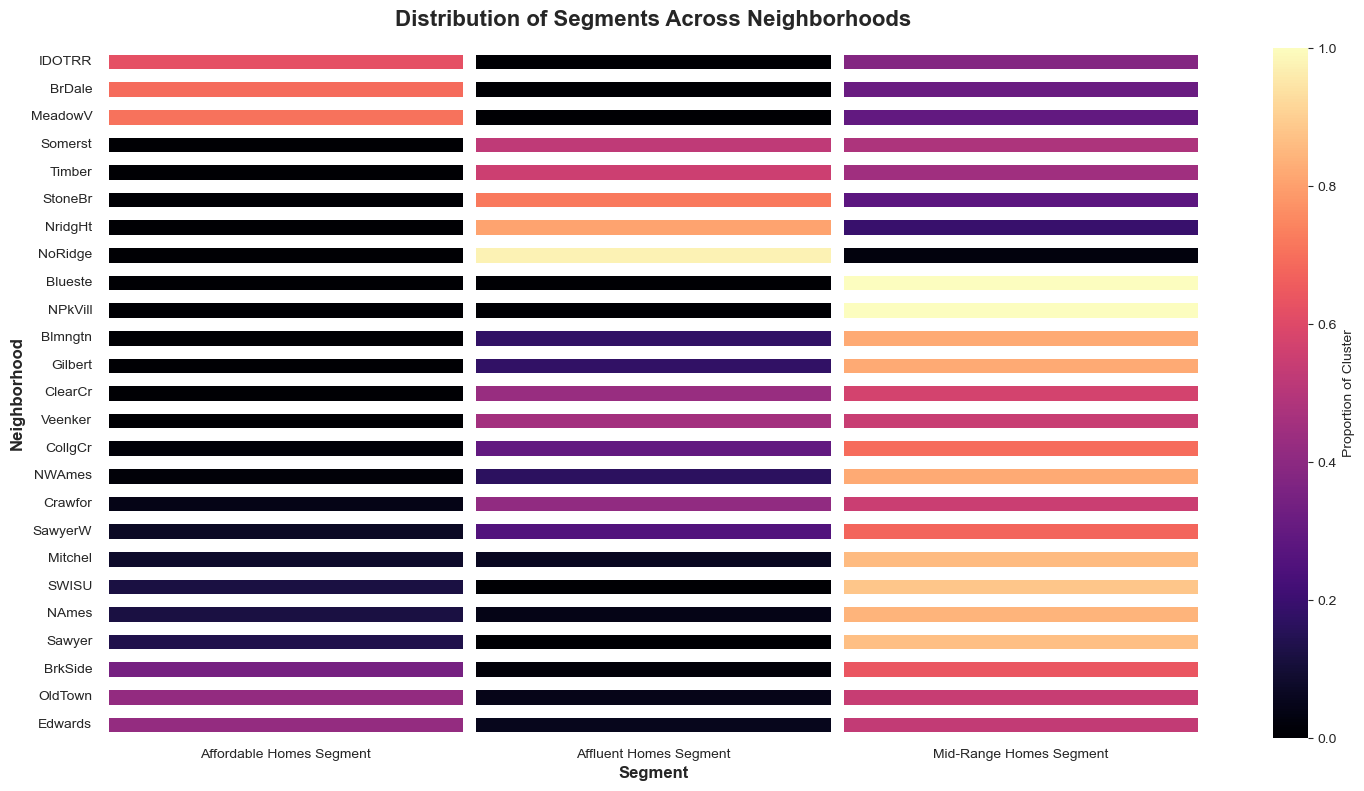

In [34]:
# Analyze the distribution of clusters across neighborhoods
neighborhood_clusters = gmm_clustering_df.groupby(['Neighborhood'])['Cluster'].value_counts(normalize=True).unstack(fill_value=0)

# Find the dominant cluster for each neighborhood
neighborhood_clusters["Dominant_Cluster"] = neighborhood_clusters.idxmax(axis=1)

# Sort neighborhoods by dominant cluster and cluster proportions
neighborhood_clusters = neighborhood_clusters.sort_values(
    by=["Dominant_Cluster"] + list(neighborhood_clusters.columns[:-1])
)

# Identify top neighborhoods for each cluster
top_neighborhoods = {}
for cluster in gmm_clustering_df['Cluster'].unique():
    top_neighborhoods[cluster] = neighborhood_clusters[cluster].nlargest(5)

# Display the top neighborhoods for each cluster
for cluster, neighborhoods in top_neighborhoods.items():
    value = gmm_clustering_df.loc[gmm_clustering_df['Cluster']==cluster, 'Cluster_label'].iloc[0]
    print(f"\nTop 5 Neighborhoods for {value}:")
    for neighborhood, proportion in neighborhoods.items():
        print(f" {neighborhood} : {proportion:.2f}")

# Visualize the distribution of clusters across neighborhoods
plt.figure(figsize=(15, 8))
ax = sns.heatmap(neighborhood_clusters.iloc[:, :-1], cmap='magma', lw=8, cbar_kws={'label': 'Proportion of Cluster'})
ax.set_xticklabels(cluster_labels)
plt.title('Distribution of Segments Across Neighborhoods', fontsize=16, fontweight='bold', y=1.02)
plt.ylabel('Neighborhood', fontsize=12, fontweight='bold')
plt.xlabel('Segment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



These are the top 5 neighborhoods for each segment:

- **Affluent Homes:** High-end properties representing the premium tier of the market.
    - NoRidge 
    - NridgHt 
    - StoneBr 
    - Timber 
    - Somerst 

- **Mid-Range Homes:** Moderately priced houses that fall within the middle range.
    -  Blueste 
    - NPkVill
    - SWISU
    - Sawyer
    - Mitchel

- **Affordable Homes:** More affordable options catering to cost-conscious buyers.
    -  MeadowV 
    - BrDale 
    - IDOTRR 
    - Edwards 
    - OldTown 
    

#### **3. Which factors best determine the price bracket of a property?**

I compared the key price-driving features across the overall Ames market and the **Affordable, Mid-Range, and Affluent** segments using Random Forest, AdaBoost, and Decision Tree Regressors. The defined datasets and modeling pipeline were used for this comparison.



================Feature Importance Analysis======================


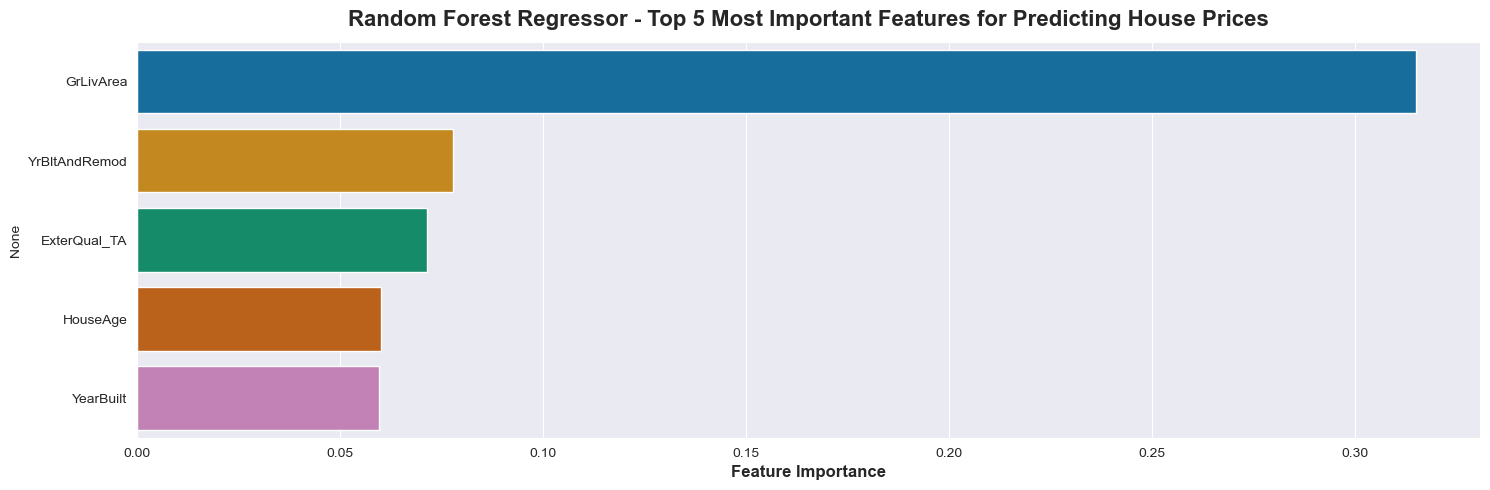

Random Forest Regressor - Top 7 most important features :
1. GrLivArea: 0.3152
2. YrBltAndRemod: 0.0780
3. ExterQual_TA: 0.0715
4. HouseAge: 0.0600
5. YearBuilt: 0.0596
6. GarageCars: 0.0564
7. TotalSF: 0.0411


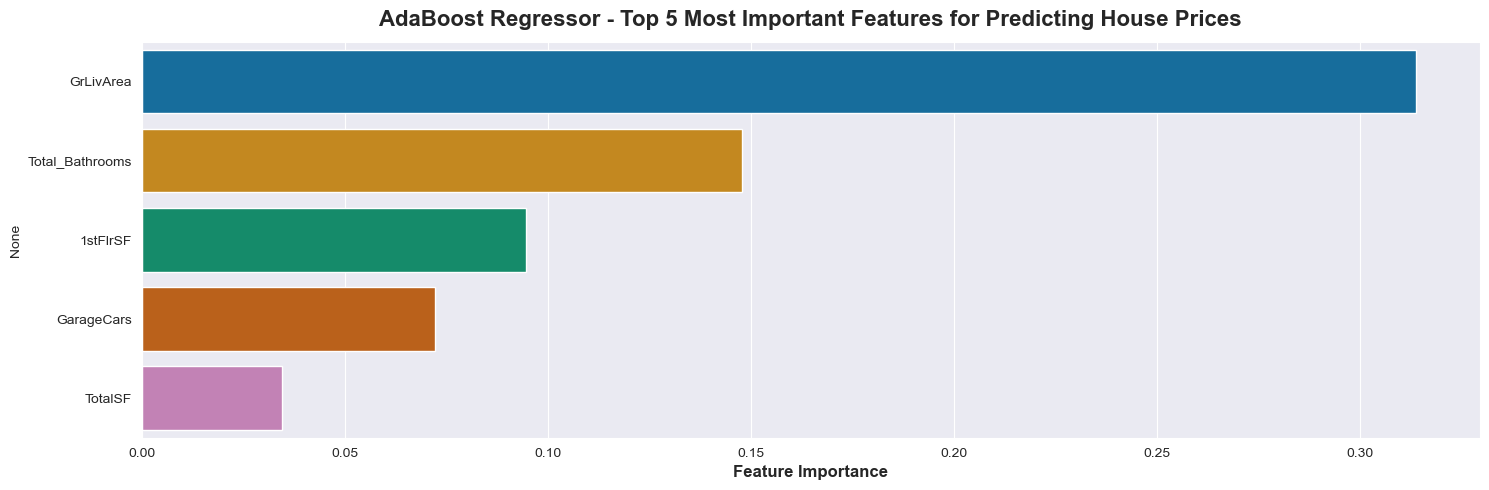

AdaBoost Regressor - Top 7 most important features :
1. GrLivArea: 0.3138
2. Total_Bathrooms: 0.1478
3. 1stFlrSF: 0.0946
4. GarageCars: 0.0721
5. TotalSF: 0.0346
6. GarageArea: 0.0317
7. HouseAge: 0.0308


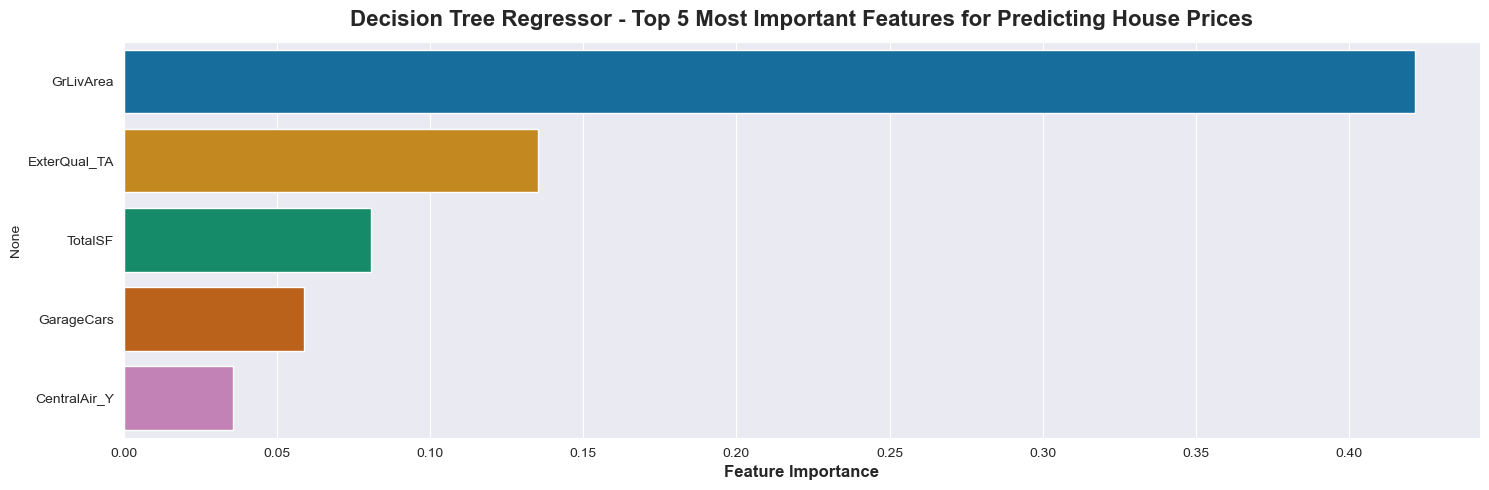

Decision Tree Regressor - Top 7 most important features :
1. GrLivArea: 0.4217
2. ExterQual_TA: 0.1353
3. TotalSF: 0.0808
4. GarageCars: 0.0587
5. CentralAir_Y: 0.0356
6. 1stFlrSF: 0.0355
7. Total_Bathrooms: 0.0319


In [36]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

def regressor_fit_and_print(title, X, y, regressor,
                            num_columns, ordinal_columns,
                            boolean_columns, cat_columns, year_columns,
                            seed=42):
    """
    Fit a regressor with preprocessing pipeline and print results
    """

    # Define preprocessing pipeline
    preprocessor = ColumnTransformer(transformers=[
        ('numeric', StandardScaler(), num_columns),
        ('ordinal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ordinal_columns),
        ('boolean', 'passthrough', boolean_columns),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_columns),
        ('year', 'passthrough', year_columns)
    ])

    # Build pipeline with preprocessing + regressor
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])

    # Fit model
    model.fit(X, y)

    # Extract feature importances (works for tree-based models)
    importances = model.named_steps['regressor'].feature_importances_
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()

    # Remove prefixes like 'numeric__', 'ordinal__', etc.
    clean_feature_names = [name.split('__')[-1] for name in feature_names]
    feature_importances = pd.Series(importances, index=clean_feature_names).sort_values(ascending=False)

    # Plot top 5 features
    plt.figure(figsize=(15, 5))
    sns.barplot(x=feature_importances.values[:5], y=feature_importances.index[:5], palette=sns.color_palette("colorblind", n_colors=5))
    plt.title(title + ' - Top 5 Most Important Features for Predicting House Prices', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print top 7 features
    print(title + " - Top 7 most important features :")
    for i, (feature, importance) in enumerate(feature_importances[:7].items(), 1):
        print(f"{i}. {feature}: {importance:.4f}")



# ==================================================
# Regression Function Applied
# ==================================================

print("\n================Feature Importance Analysis======================")
model_pipeline = {
    'Random Forest Regressor' : RandomForestRegressor(random_state=42),
    'AdaBoost Regressor' : AdaBoostRegressor(random_state=42),
    'Decision Tree Regressor' : DecisionTreeRegressor(random_state=42)
    }


for name, models in model_pipeline.items():
    regressor_fit_and_print(name, X_train, y_train, models,
                        num_columns=num_columns,
                        ordinal_columns=ordinal_columns,
                        boolean_columns=boolean_columns,
                        cat_columns=cat_columns,
                        year_columns=year_columns, seed=42)
    

Based on the regression results, these seven features have the greatest influence on housing prices in the overall market

* __Random Forest Regressor__ 
    - GrLivArea : Above-ground living area
    - YrBltAndRemod : Combined years since the house was built and any renovations
    - ExterQual_TA : Quality of the exterior material
    - HouseAge : Age of the house at sale
    - YearBuilt : Year house was built
    - GarageCars : Number of cars the garage can hold
    - TotalSF : Total area in square feet of the house

* __AdaBoost Regressor__ 
    -  GrLivArea : Above-ground living area
    -  Total_Bathrooms : Total number of bathrooms in the house
    -  1stFlrSF : First-floor area in square feet
    -  GarageCars : Number of cars the garage can hold
    -  TotalSF : Total area in square feet of the house
    -  GarageArea : Size of the garage
    -  HouseAge

* __Decision Tree Regressor__
    - GrLivArea : Above-ground living area
    - ExterQual_TA : Quality of the exterior material
    - TotalSF : Total area in square feet of the house
    - GarageCars : Number of cars the garage can hold
    - CentralAir_Y : Has Central air conditioning
    - 1stFlrSF : First-floor area
    - Total_Bathrooms : Total number of bathrooms in the house


### **Summary**

Based on the regressor results, several primary factors strongly influence house sale prices:

| Category | Key Finding |
|---|---|
| **Property Size** | Total and above-ground living areas significantly influence house value. |
| **Property Age & Renovation** | House age, construction year, and renovation history are influential factors. |
| **Garage Attributes** | Garage size and capacity are significant predictors of house price. |
| **Total Bathrooms** | The number of bathrooms is an important predictor of house value. |
| **Exterior Characteristics** | Average exterior quality is an important factor in determining house prices. |

Understanding these features helps identify the key factors influencing house value.



## **6. SalePrice Predictors for Affordable, Mid-Range, and Affluent Homes**

Analyzed Affordable, Mid-Range, and Affluent Homes separately to identify the key factors influencing prices in each segment & buyer preferences.


In [ ]:
(gmm_clustering_df['Cluster_label'].value_counts(normalize=True)*100).round(2)

Cluster_label
Mid-Range Home Segment     62.83
Affluent Home Segment      22.98
Affordable Home Segment    14.20
Name: proportion, dtype: float64

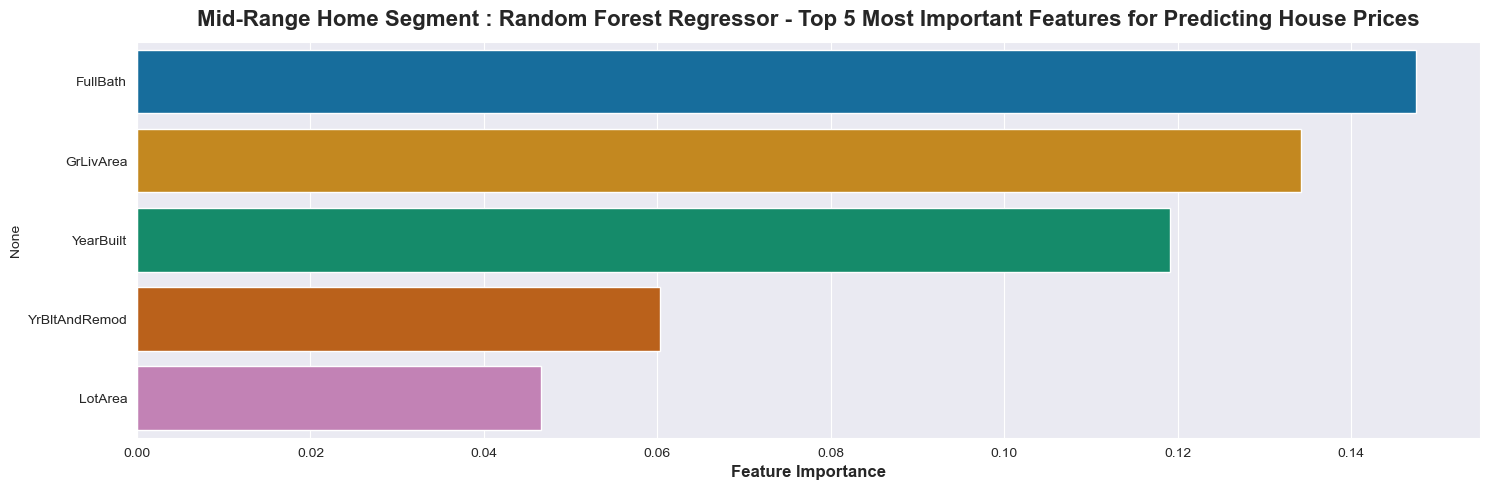

Mid-Range Home Segment : Random Forest Regressor - Top 7 most important features :
1. FullBath: 0.1475
2. GrLivArea: 0.1342
3. YearBuilt: 0.1191
4. YrBltAndRemod: 0.0602
5. LotArea: 0.0465
6. HouseAge: 0.0463
7. 1stFlrSF: 0.0399


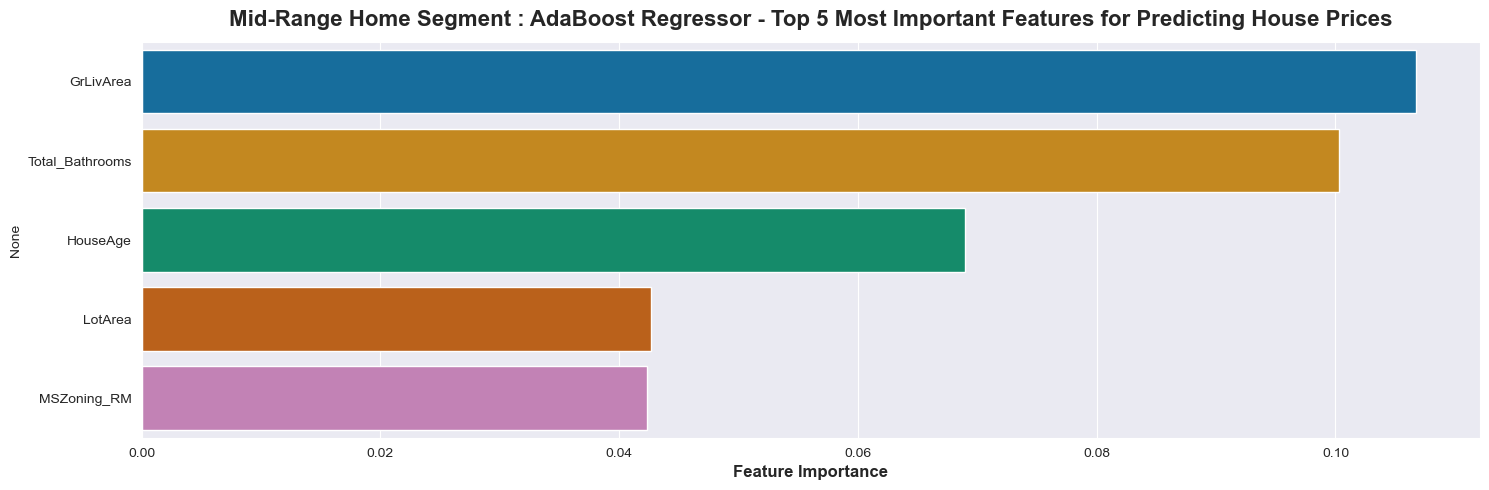

Mid-Range Home Segment : AdaBoost Regressor - Top 7 most important features :
1. GrLivArea: 0.1068
2. Total_Bathrooms: 0.1003
3. HouseAge: 0.0689
4. LotArea: 0.0427
5. MSZoning_RM: 0.0424
6. OverallQual_5: 0.0411
7. GarageArea: 0.0361


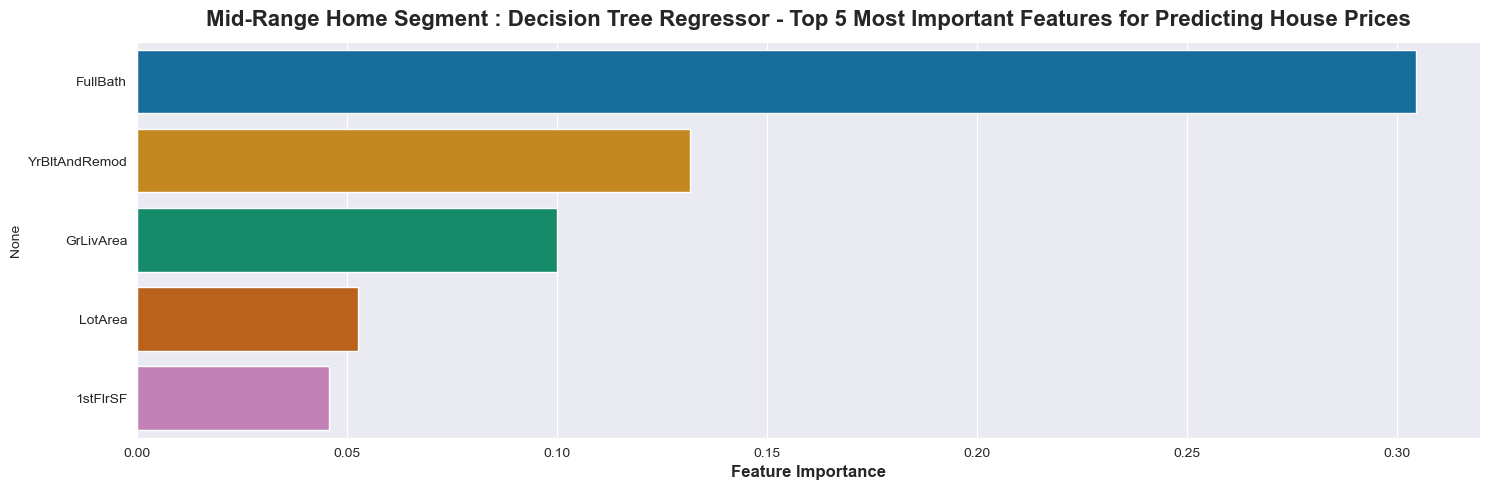

Mid-Range Home Segment : Decision Tree Regressor - Top 7 most important features :
1. FullBath: 0.3045
2. YrBltAndRemod: 0.1315
3. GrLivArea: 0.0999
4. LotArea: 0.0526
5. 1stFlrSF: 0.0456
6. MSSubClass_60: 0.0312
7. GarageArea: 0.0287


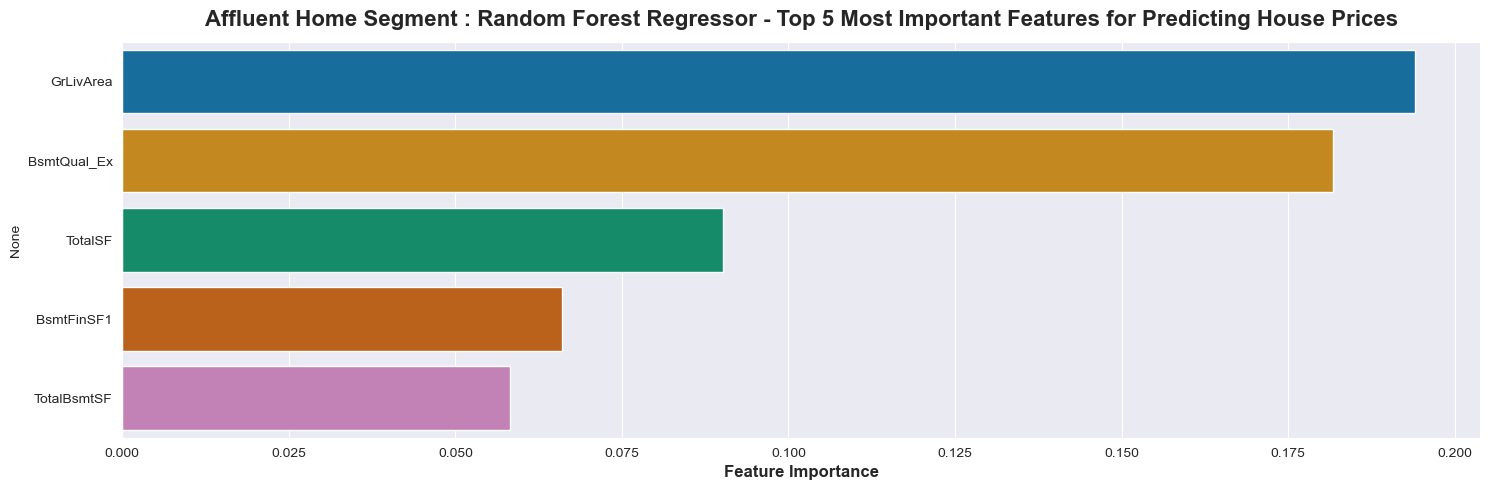

Affluent Home Segment : Random Forest Regressor - Top 7 most important features :
1. GrLivArea: 0.1941
2. BsmtQual_Ex: 0.1817
3. TotalSF: 0.0902
4. BsmtFinSF1: 0.0660
5. TotalBsmtSF: 0.0581
6. TotRmsAbvGrd: 0.0385
7. ExterQualCond_ExTA: 0.0319


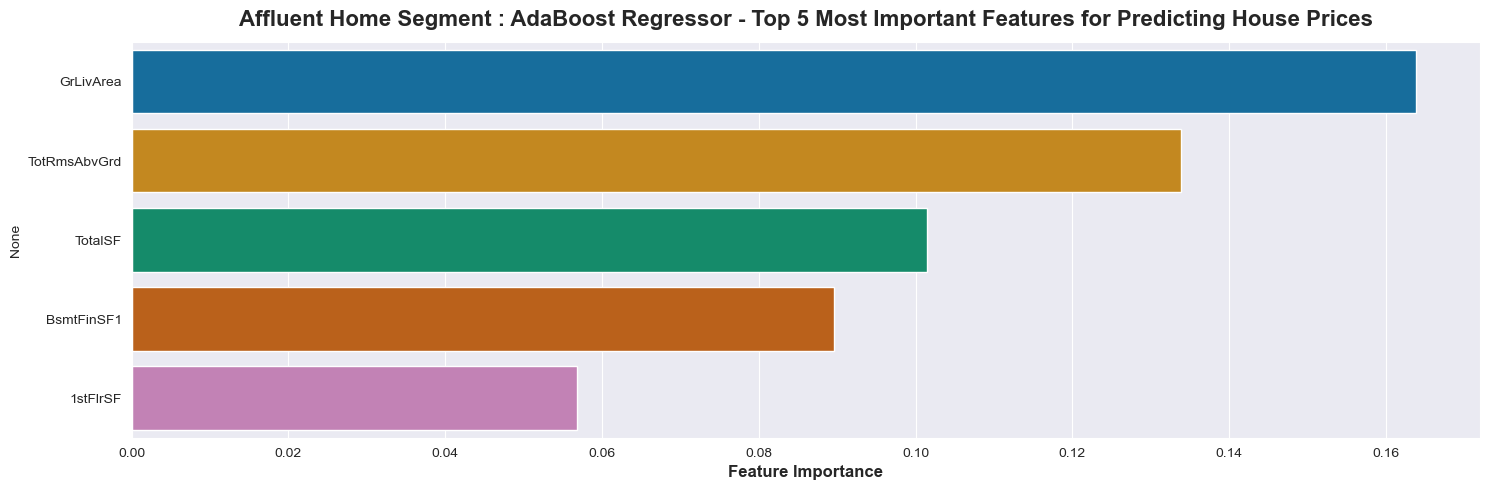

Affluent Home Segment : AdaBoost Regressor - Top 7 most important features :
1. GrLivArea: 0.1638
2. TotRmsAbvGrd: 0.1339
3. TotalSF: 0.1015
4. BsmtFinSF1: 0.0896
5. 1stFlrSF: 0.0569
6. KitchenQual_Ex: 0.0442
7. OverallQual_10: 0.0342


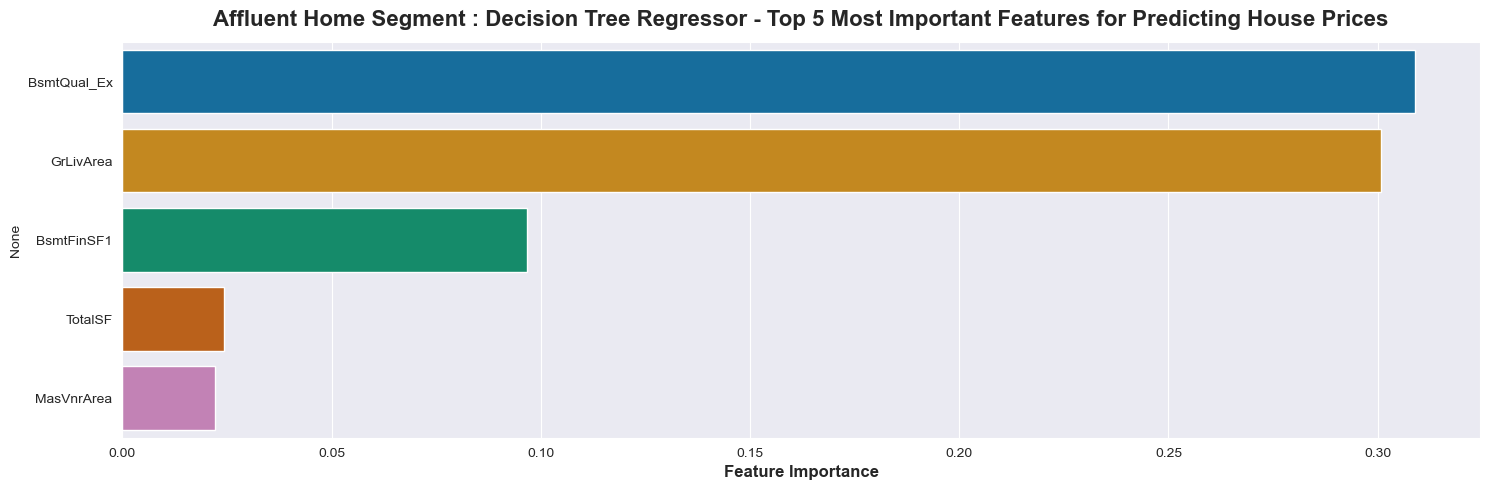

Affluent Home Segment : Decision Tree Regressor - Top 7 most important features :
1. BsmtQual_Ex: 0.3090
2. GrLivArea: 0.3008
3. BsmtFinSF1: 0.0967
4. TotalSF: 0.0243
5. MasVnrArea: 0.0222
6. TotalBsmtSF: 0.0214
7. GarageCars: 0.0194


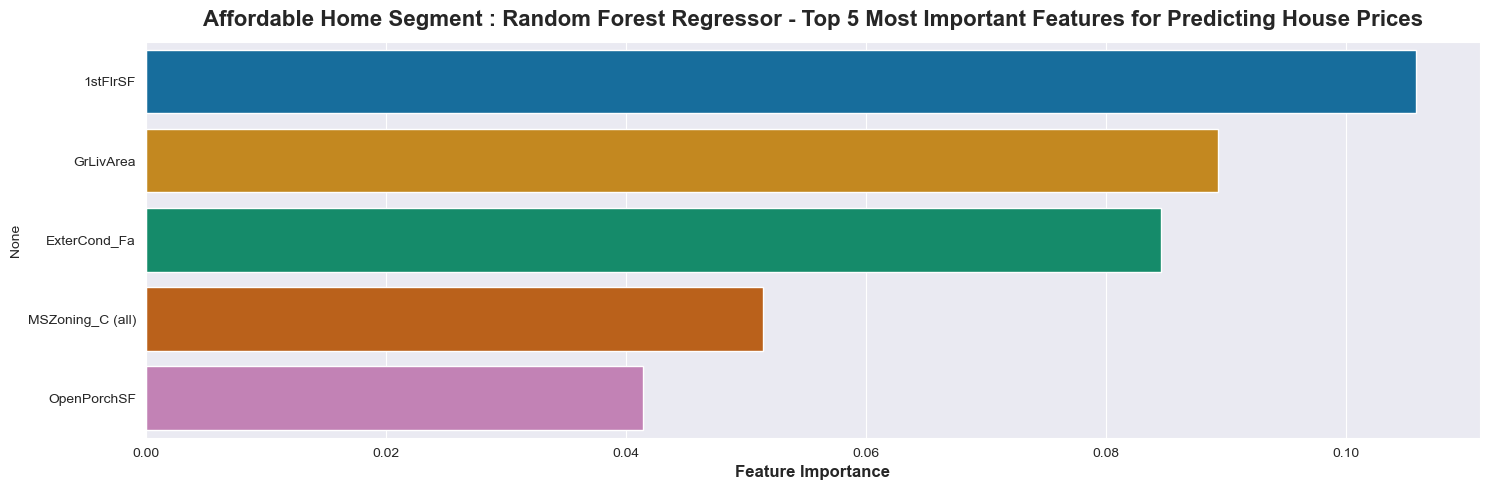

Affordable Home Segment : Random Forest Regressor - Top 7 most important features :
1. 1stFlrSF: 0.1059
2. GrLivArea: 0.0893
3. ExterCond_Fa: 0.0845
4. MSZoning_C (all): 0.0514
5. OpenPorchSF: 0.0414
6. LotArea: 0.0323
7. Heating_Grav: 0.0316


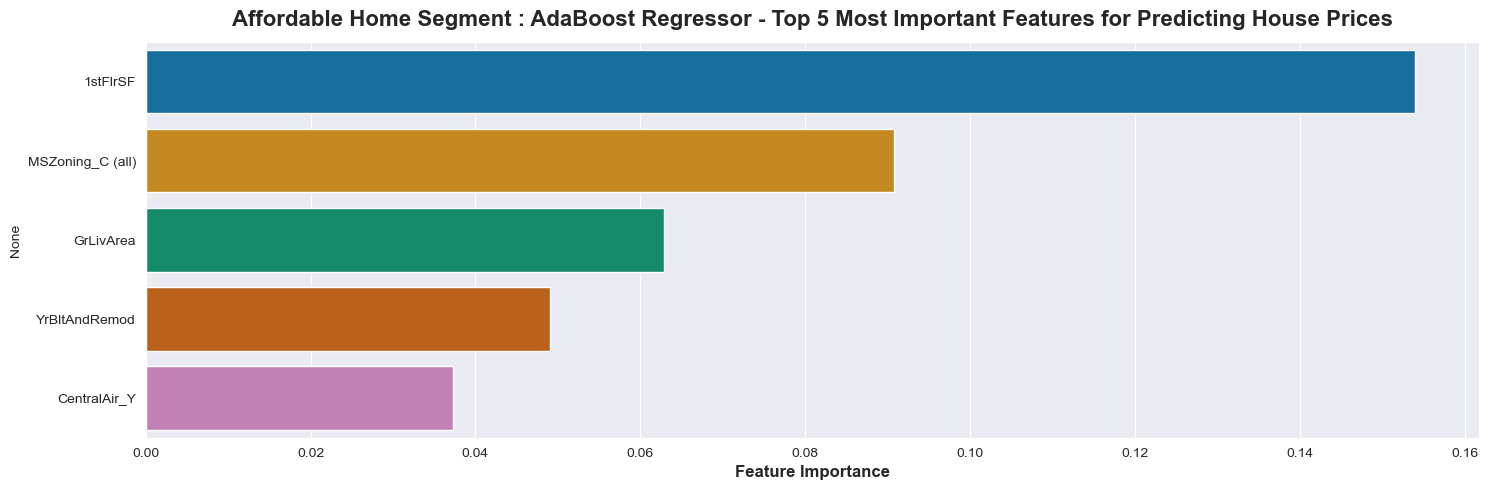

Affordable Home Segment : AdaBoost Regressor - Top 7 most important features :
1. 1stFlrSF: 0.1540
2. MSZoning_C (all): 0.0908
3. GrLivArea: 0.0628
4. YrBltAndRemod: 0.0490
5. CentralAir_Y: 0.0372
6. GarageArea: 0.0370
7. CentralAir_N: 0.0313


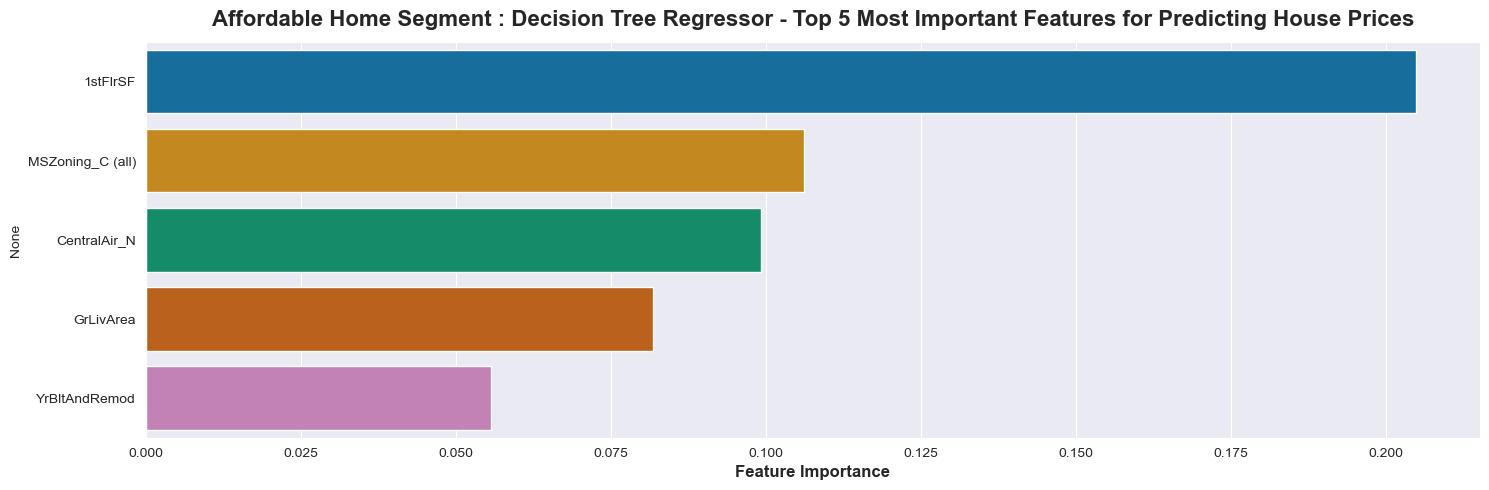

Affordable Home Segment : Decision Tree Regressor - Top 7 most important features :
1. 1stFlrSF: 0.2050
2. MSZoning_C (all): 0.1062
3. CentralAir_N: 0.0992
4. GrLivArea: 0.0818
5. YrBltAndRemod: 0.0558
6. LotArea: 0.0477
7. ExterQual_Fa: 0.0364


In [37]:
for i in gmm_clustering_df['Cluster'].unique():
    cluster_data = gmm_clustering_df[gmm_clustering_df['Cluster'] == i]
    cluster_label = gmm_clustering_df.loc[gmm_clustering_df['Cluster'] == i, 'Cluster_label'].iloc[0]
    X_cluster = cluster_data[total_features]
    y_cluster = cluster_data['LogSalePrice']

    model_pipeline = {
    'Random Forest Regressor' : RandomForestRegressor(random_state=42),
    'AdaBoost Regressor' : AdaBoostRegressor(random_state=42),
    'Decision Tree Regressor' : DecisionTreeRegressor(random_state=42)
    }


    for model_name, models in model_pipeline.items():
        regressor_fit_and_print(f"{cluster_label} : {model_name}", X_cluster, y_cluster, models,
                                num_columns=num_columns,
                                ordinal_columns=ordinal_columns,
                                boolean_columns=boolean_columns,
                                cat_columns=cat_columns,
                                year_columns=year_columns, seed=42)
        


### **Conclusions**

Comparing the top five features across affordable, mid-range, and affluent homes reveals segment-specific factors that drive sale prices beyond the common market drivers.

### **Affordable House Segment**

- **First Floor Area (`1stFlrSF`)**: A larger first-floor area increases house value.
- **Exterior Condition (`ExterCond`)**: Fair exterior condition influences the sale price.
- **Open Porch Area (`OpenPorchSF`)**: Larger open porch areas contribute to higher prices.
- **Zoning (`MSZoning`)**: Commercial zoning is associated with higher sale prices.

### **Mid-Range House Segment**

- **Full Bathrooms (`FullBath`)**: More full bathrooms significantly impact the sale price.
- **Zoning (`MSZoning`)**: Medium-density residential zoning is valuable in this segment.
- **Property Size (`LotArea`)**: Larger land areas are associated with higher house prices.

### **Affluent House Segment**

- **Basement Features (`BsmtFinSF1`, `TotalBsmtSF`, `BsmtQual`)**: Basement size, finished area, and excellent quality significantly influence luxury home prices.
- **Living Space & Rooms (`TotRmsAbvGrd`)**: More above-ground rooms are associated with higher home values.
- **Exterior Attributes (`MasVnrArea`)**: Larger masonry veneer areas are associated with higher property sale prices.

Understanding segment-specific drivers helps improve home price prediction and evaluation, while further analysis can uncover additional influencing factors.



#### **Closing Reflection**

What began as a simple resume project became a valuable learning experience in applying data science techniques, including:


- Defining clear objectives
- Exploring and visualizing data
- Detecting and removing outliers
- Correcting skewed distributions
- Managing missing values
- Normalizing numerical features
- Performing bivariate analysis
- Deriving insights from the Ames housing market

This project strengthened my understanding of **CRISP-DM** and sparked further interest in **data science field**.

---

#### **Directions of Future Work**

A key next step is to develop a **predictive model** for Ames home prices to improve pricing accuracy and identify potential investment opportunities.


***